# DDPM vs DDIM — 커스텀 데이터 학습과 샘플링 스텝 수 비교

직접 모은 포켓몬 스프라이트 이미지(약 800장)를 폴더에서 직접 불러와 DDPM 을 학습하고,  
**DDIM(Denoising Diffusion Implicit Models)** 샘플러를 구현하여 **샘플링 스텝 수 T에 따라 DDPM 과 DDIM 의 속도·품질을 비교**한다.

### 0. 설치 / 한글 폰트 / 임포트

In [2]:
!pip3 -q install einops imageio

In [3]:
# matplotlib 한글 폰트 (그래프 한글 깨짐 방지)
!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib.font_manager as fm, matplotlib.pyplot as plt
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"; plt.rcParams["axes.unicode_minus"] = False
print("폰트 설정 완료")

폰트 설정 완료


In [4]:
import os, math, random, glob, zipfile, time
import numpy as np
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import einops

SEED=0; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device,
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

Using device: cuda Tesla T4


### 1. 데이터 업로드 및 압축 해제

In [5]:
from google.colab import files
uploaded = files.upload()                 # pokemon.zip 선택
zip_name = list(uploaded.keys())[0]
DATA_DIR = "./pokemon"; os.makedirs(DATA_DIR, exist_ok=True)
with zipfile.ZipFile(zip_name, "r") as zf: zf.extractall(DATA_DIR)
n = len(glob.glob(os.path.join(DATA_DIR,"**","*.png"),recursive=True) +
        glob.glob(os.path.join(DATA_DIR,"**","*.jpg"),recursive=True))
print(f"이미지 {n} 장")

Saving pokemon.zip to pokemon.zip
이미지 809 장


### 2. 커스텀 Dataset

데이터셋 크기: 809


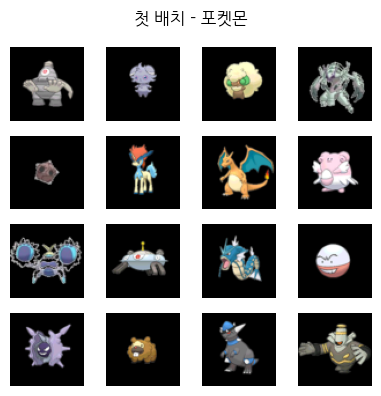

In [6]:
IMG_SIZE = 64
CHANNELS = 3

class FolderImageDataset(Dataset):
    # 폴더의 이미지 파일을 직접 읽는 커스텀 데이터셋 (torchvision 빌트인 로더 미사용).
    def __init__(self, root, img_size=64, channels=3):
        self.paths = sorted(
            glob.glob(os.path.join(root,"**","*.png"),recursive=True) +
            glob.glob(os.path.join(root,"**","*.jpg"),recursive=True) +
            glob.glob(os.path.join(root,"**","*.jpeg"),recursive=True))
        if not self.paths: raise RuntimeError(f"{root} 에 이미지가 없습니다.")
        self.img_size=img_size; self.channels=channels

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx])
        # 투명(RGBA)이면 검정 배경에 합성, 아니면 그대로 RGB
        if img.mode == "RGBA":
            bg = Image.new("RGBA", img.size, (0,0,0,255))
            img = Image.alpha_composite(bg, img)
        img = img.convert("RGB").resize((self.img_size,self.img_size), Image.BILINEAR)
        arr = np.asarray(img, np.float32)/255.0
        arr = arr.transpose(2,0,1)
        x = torch.from_numpy(arr)
        return (x - 0.5)*2.0, 0     # [-1,1]

def show_images(images, title=""):
    # 이미지별 값 범위를 [-1,1]->[0,1] 로 clip 하여 표시.
    if isinstance(images, torch.Tensor): images = images.detach().cpu().numpy()
    imgs = np.clip((images+1)/2, 0, 1)
    n=len(imgs); rows=int(n**0.5); cols=math.ceil(n/rows)
    fig=plt.figure(figsize=(cols,rows))
    for i in range(n):
        ax=fig.add_subplot(rows,cols,i+1)
        ax.imshow(imgs[i].transpose(1,2,0)); ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

dataset = FolderImageDataset(DATA_DIR, IMG_SIZE, CHANNELS)
print("데이터셋 크기:", len(dataset))
loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, drop_last=True)
xb,_ = next(iter(loader)); show_images(xb[:16], "첫 배치 - 포켓몬")

### 3. 디퓨전 모듈 (forward + 노이즈 스케줄)

forward(노이즈 추가)과정과 베타/알파 스케줄만 담는 컨테이너다.  
DDPM·DDIM 의 reverse 과정은 이 모듈의 계수(`alphas`, `alpha_bars`)를 공유하되 **별도 샘플러 함수**로 구현한다.

In [7]:
class Diffusion(nn.Module):
    def __init__(self, network, n_steps=500, min_beta=1e-4, max_beta=0.02,
                 device=None, image_chw=(3,64,64)):
        super().__init__()
        self.n_steps=n_steps; self.device=device; self.image_chw=image_chw
        self.network=network.to(device)
        self.betas=torch.linspace(min_beta,max_beta,n_steps).to(device)
        self.alphas=1-self.betas
        self.alpha_bars=torch.cumprod(self.alphas,dim=0).to(device)

    def forward(self, x0, t, eta=None):
        # 임의 시점 t 까지 한 번에 노이즈 추가 (closed form)
        n,c,h,w=x0.shape; a_bar=self.alpha_bars[t]
        if eta is None: eta=torch.randn(n,c,h,w).to(self.device)
        return a_bar.sqrt().reshape(n,1,1,1)*x0 + (1-a_bar).sqrt().reshape(n,1,1,1)*eta

    def predict_noise(self, x, t):
        # 네트워크가 추정한 노이즈 ε_θ(x_t, t)
        return self.network(x, t)

### 4. U-Net (정현파 시간 임베딩, 64→32→16→8 인코더-디코더)
본 과제에서는 기본 구조(width=1.0) 하나만 학습해
DDPM·DDIM 비교에 집중한다.

In [8]:
def sinusoidal_embedding(n, d):
    emb=torch.zeros(n,d)
    wk=torch.tensor([1/10_000**(2*j/d) for j in range(d)]).reshape(1,d)
    t=torch.arange(n).reshape(n,1)
    emb[:,::2]=torch.sin(t*wk[:,::2]); emb[:,1::2]=torch.cos(t*wk[:,::2])
    return emb

class MyBlock(nn.Module):
    def __init__(self, shape, in_c, out_c, ks=3, st=1, pad=1, normalize=True):
        super().__init__()
        self.ln=nn.LayerNorm(shape)
        self.conv1=nn.Conv2d(in_c,out_c,ks,st,pad); self.conv2=nn.Conv2d(out_c,out_c,ks,st,pad)
        self.act=nn.SiLU(); self.normalize=normalize
    def forward(self,x):
        out=self.ln(x) if self.normalize else x
        return self.act(self.conv2(self.act(self.conv1(out))))

class MyUNet(nn.Module):
    def __init__(self, n_steps=500, time_emb_dim=100, width=1.0, in_ch=3):
        super().__init__()
        c1,c2,c3=int(10*width),int(20*width),int(40*width)
        self.time_embed=nn.Embedding(n_steps,time_emb_dim)
        self.time_embed.weight.data=sinusoidal_embedding(n_steps,time_emb_dim); self.time_embed.requires_grad_(False)
        def te(d): return nn.Sequential(nn.Linear(time_emb_dim,d),nn.SiLU(),nn.Linear(d,d))
        self.te1=te(in_ch); self.b1=nn.Sequential(MyBlock((in_ch,64,64),in_ch,c1),MyBlock((c1,64,64),c1,c1))
        self.down1=nn.Conv2d(c1,c1,4,2,1)
        self.te2=te(c1); self.b2=nn.Sequential(MyBlock((c1,32,32),c1,c2),MyBlock((c2,32,32),c2,c2))
        self.down2=nn.Conv2d(c2,c2,4,2,1)
        self.te3=te(c2); self.b3=nn.Sequential(MyBlock((c2,16,16),c2,c3),MyBlock((c3,16,16),c3,c3))
        self.down3=nn.Conv2d(c3,c3,4,2,1)
        self.te_mid=te(c3); self.b_mid=nn.Sequential(MyBlock((c3,8,8),c3,c3),MyBlock((c3,8,8),c3,c3))
        self.up1=nn.ConvTranspose2d(c3,c3,4,2,1)
        self.te4=te(c3*2); self.b4=nn.Sequential(MyBlock((c3*2,16,16),c3*2,c2),MyBlock((c2,16,16),c2,c2))
        self.up2=nn.ConvTranspose2d(c2,c2,4,2,1)
        self.te5=te(c2*2); self.b5=nn.Sequential(MyBlock((c2*2,32,32),c2*2,c1),MyBlock((c1,32,32),c1,c1))
        self.up3=nn.ConvTranspose2d(c1,c1,4,2,1)
        self.te_out=te(c1*2); self.b_out=nn.Sequential(MyBlock((c1*2,64,64),c1*2,c1),MyBlock((c1,64,64),c1,c1,normalize=False))
        self.conv_out=nn.Conv2d(c1,in_ch,3,1,1)
    def forward(self,x,t):
        t=self.time_embed(t); n=len(x)
        o1=self.b1(x+self.te1(t).reshape(n,-1,1,1))
        o2=self.b2(self.down1(o1)+self.te2(t).reshape(n,-1,1,1))
        o3=self.b3(self.down2(o2)+self.te3(t).reshape(n,-1,1,1))
        om=self.b_mid(self.down3(o3)+self.te_mid(t).reshape(n,-1,1,1))
        o4=self.b4(torch.cat((o3,self.up1(om)),1)+self.te4(t).reshape(n,-1,1,1))
        o5=self.b5(torch.cat((o2,self.up2(o4)),1)+self.te5(t).reshape(n,-1,1,1))
        o=self.b_out(torch.cat((o1,self.up3(o5)),1)+self.te_out(t).reshape(n,-1,1,1))
        return self.conv_out(o)

### 5. 학습 루프

각 배치에서 무작위 시점 t 와 노이즈 ε 를 뽑아 noisy 이미지를 만들고,
네트워크가 ε 를 예측하도록 MSE 로 학습한다.

In [9]:
def training_loop(diff, loader, n_epochs, optim, device, store_path="model.pt"):
    mse=nn.MSELoss(); best=float("inf"); hist=[]
    for epoch in tqdm(range(n_epochs), desc="학습 진행"):
        ep=0.0
        for batch in loader:
            x0=batch[0].to(device); n=len(x0)
            eta=torch.randn_like(x0).to(device)
            t=torch.randint(0,diff.n_steps,(n,)).to(device)
            noisy=diff(x0,t,eta)
            eta_pred=diff.predict_noise(noisy, t.reshape(n,-1))
            loss=mse(eta_pred, eta)
            optim.zero_grad(); loss.backward(); optim.step()
            ep+=loss.item()*len(x0)/len(loader.dataset)
        hist.append(ep)
        msg=f"에폭 {epoch+1} 손실: {ep:.4f}"
        if ep<best: best=ep; torch.save(diff.state_dict(),store_path); msg+="  --> 저장"
        print(msg)
    return hist

### 6. 모델 학습

학습 단계 수 `T_TRAIN=500`, 컬러 64×64. 비교의 핵심은 샘플링이므로 모델은 하나만 학습한다.  

In [10]:
T_TRAIN=500; n_epochs=100; lr=1e-3
net=MyUNet(T_TRAIN, width=1.0, in_ch=CHANNELS)
diff=Diffusion(net, n_steps=T_TRAIN, device=device, image_chw=(CHANNELS,IMG_SIZE,IMG_SIZE))
print("파라미터 수:", sum(p.numel() for p in diff.parameters()))
hist=training_loop(diff, loader, n_epochs, Adam(diff.parameters(),lr), device, "ddpm_pokemon.pt")

파라미터 수: 918274


학습 진행:   0%|          | 0/100 [00:00<?, ?it/s]

에폭 1 손실: 0.9431  --> 저장
에폭 2 손실: 0.8653  --> 저장
에폭 3 손실: 0.7375  --> 저장
에폭 4 손실: 0.6331  --> 저장
에폭 5 손실: 0.5535  --> 저장
에폭 6 손실: 0.4893  --> 저장
에폭 7 손실: 0.4315  --> 저장
에폭 8 손실: 0.3934  --> 저장
에폭 9 손실: 0.3594  --> 저장
에폭 10 손실: 0.3287  --> 저장
에폭 11 손실: 0.3017  --> 저장
에폭 12 손실: 0.2563  --> 저장
에폭 13 손실: 0.2384  --> 저장
에폭 14 손실: 0.2040  --> 저장
에폭 15 손실: 0.1765  --> 저장
에폭 16 손실: 0.1478  --> 저장
에폭 17 손실: 0.1478
에폭 18 손실: 0.1297  --> 저장
에폭 19 손실: 0.1209  --> 저장
에폭 20 손실: 0.1108  --> 저장
에폭 21 손실: 0.1006  --> 저장
에폭 22 손실: 0.1101
에폭 23 손실: 0.1010
에폭 24 손실: 0.0998  --> 저장
에폭 25 손실: 0.0967  --> 저장
에폭 26 손실: 0.0900  --> 저장
에폭 27 손실: 0.0894  --> 저장
에폭 28 손실: 0.0863  --> 저장
에폭 29 손실: 0.0831  --> 저장
에폭 30 손실: 0.0795  --> 저장
에폭 31 손실: 0.0847
에폭 32 손실: 0.0877
에폭 33 손실: 0.0777  --> 저장
에폭 34 손실: 0.0716  --> 저장
에폭 35 손실: 0.0981
에폭 36 손실: 0.0786
에폭 37 손실: 0.0795
에폭 38 손실: 0.0800
에폭 39 손실: 0.0690  --> 저장
에폭 40 손실: 0.0744
에폭 41 손실: 0.0653  --> 저장
에폭 42 손실: 0.0651  --> 저장
에폭 43 손실: 0.0704
에폭 44 손실: 0.0643  --> 

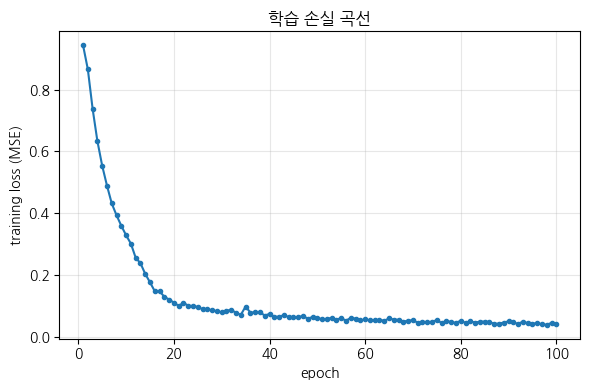

In [11]:
# 학습 손실 곡선
plt.figure(figsize=(6,4))
plt.plot(range(1,len(hist)+1), hist, marker="o", ms=3)
plt.xlabel("epoch"); plt.ylabel("training loss (MSE)")
plt.title("학습 손실 곡선"); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig("loss_curve.png", dpi=120); plt.show()

In [12]:
# 베스트 모델 로드
diff.load_state_dict(torch.load("ddpm_pokemon.pt", map_location=device))
diff.eval(); print("베스트 모델 로드 완료")

베스트 모델 로드 완료


## 7. 샘플러 구현 — DDPM vs DDIM

두 샘플러 모두 **같은 학습된 네트워크 `diff.predict_noise`** 를 사용한다. 차이는 reverse 수식뿐이다.

### 7.1 DDPM 샘플러 (ancestral sampling)
표준 DDPM 은 학습한 전체 스텝 수 T 만큼 한 스텝씩 거꾸로 내려간다.  
매 스텝 예측한 노이즈로 posterior 평균을 구하고, 분산만큼의 가우시안 노이즈를 더한다.
발산을 막기 위해 매 스텝 예측 x₀ 를 [-1,1] 로 clamp 한다.

In [13]:
@torch.no_grad()
def sample_ddpm(diff, n_samples=16, device=None, c=3, h=64, w=64):
    device = device or diff.device; diff.eval()
    x = torch.randn(n_samples,c,h,w).to(device)
    for t in list(range(diff.n_steps))[::-1]:
        tt=(torch.ones(n_samples,1)*t).to(device).long()
        eta=diff.predict_noise(x,tt)
        a_t=diff.alphas[t]; ab_t=diff.alpha_bars[t]; b_t=diff.betas[t]
        x0_pred=((x-(1-ab_t).sqrt()*eta)/ab_t.sqrt()).clamp(-1,1)
        if t>0:
            ab_prev=diff.alpha_bars[t-1]
            cx0=(ab_prev.sqrt()*b_t)/(1-ab_t); cxt=(a_t.sqrt()*(1-ab_prev))/(1-ab_t)
            mean=cx0*x0_pred+cxt*x
            var=(1-ab_prev)/(1-ab_t)*b_t
            x=mean+var.sqrt()*torch.randn(n_samples,c,h,w).to(device)
        else:
            x=x0_pred
    return x

### 7.2 DDIM 샘플러 (스텝 건너뛰기)

DDIM은 forward 를 **non-Markovian** 과정으로 재정의하여
같은 학습 목표를 유지하면서 **일부 시점만 골라 빠르게** 생성할 수 있게 한다.

`eta=0` 이면 (sigma_t=0)인 **deterministic** 샘플링이 된다(노이즈 추가 없음).  
`eta=1` 이면 DDPM 과 동일한 확률적 샘플링에 해당한다. 본 과제에서는 기본 `eta=0` 을 쓴다.

In [14]:
@torch.no_grad()
def sample_ddim(diff, n_samples=16, n_ddim=50, eta=0.0, device=None, c=3, h=64, w=64):
    device = device or diff.device; diff.eval()
    # 전체 [0, T-1] 에서 n_ddim 개의 시점을 등간격으로 선택 (오름차순)
    step_seq = np.linspace(0, diff.n_steps-1, n_ddim).round().astype(int)
    step_seq = np.unique(step_seq)
    x = torch.randn(n_samples,c,h,w).to(device)
    for i in reversed(range(len(step_seq))):
        t = int(step_seq[i])
        t_prev = int(step_seq[i-1]) if i>0 else -1
        tt=(torch.ones(n_samples,1)*t).to(device).long()
        eta_pred=diff.predict_noise(x,tt)
        ab_t=diff.alpha_bars[t]
        ab_prev=diff.alpha_bars[t_prev] if t_prev>=0 else torch.tensor(1.0, device=device)
        # 예측 x0
        x0_pred=((x-(1-ab_t).sqrt()*eta_pred)/ab_t.sqrt()).clamp(-1,1)
        # 확률성 계수 sigma (eta=0 이면 0 -> 결정론적)
        sigma = eta * (((1-ab_prev)/(1-ab_t))*(1-ab_t/ab_prev)).clamp(min=0).sqrt()
        # x_{t_prev} 방향 항
        dir_xt=(1-ab_prev-sigma**2).clamp(min=0).sqrt()*eta_pred
        x = ab_prev.sqrt()*x0_pred + dir_xt
        if sigma>0 and t_prev>=0:
            x = x + sigma*torch.randn_like(x)
    return x

## 8. 비교 실험 — 샘플링 스텝 수 T 변화

DDPM 은 항상 전체 500 스텝을 돈다(스텝 수를 줄이면 학습된 스케줄과 어긋나 품질이 급격히 나빠진다).  
DDIM 은 **10 / 20 / 50 / 100 스텝**만으로 생성할 수 있다.

각 설정의 **wall-clock** 과 **생성 샘플**을 함께 기록해 속도·품질을 비교한다.
공정한 비교를 위해 모든 설정에서 동일한 초기 노이즈 시드를 사용한다.

In [15]:
def timed_sample(fn, **kw):
    if device.type=="cuda": torch.cuda.synchronize()
    t0=time.time()
    torch.manual_seed(123)   # 모든 설정 동일 초기 노이즈
    out=fn(**kw)
    if device.type=="cuda": torch.cuda.synchronize()
    return out, time.time()-t0

N_SHOW=16
configs=[]
# DDPM: 전체 스텝(500)
g,sec=timed_sample(sample_ddpm, diff=diff, n_samples=N_SHOW, device=device,
                   c=CHANNELS,h=IMG_SIZE,w=IMG_SIZE)
configs.append(("DDPM (500 스텝)", 500, sec, g))
print(f"DDPM 500스텝: {sec:.2f}s")

# DDIM: 다양한 스텝 수
for k in [10,20,50,100]:
    g,sec=timed_sample(sample_ddim, diff=diff, n_samples=N_SHOW, n_ddim=k, eta=0.0,
                       device=device, c=CHANNELS,h=IMG_SIZE,w=IMG_SIZE)
    configs.append((f"DDIM ({k} 스텝)", k, sec, g))
    print(f"DDIM {k}스텝: {sec:.2f}s")

DDPM 500스텝: 3.16s
DDIM 10스텝: 0.17s
DDIM 20스텝: 0.14s
DDIM 50스텝: 0.33s
DDIM 100스텝: 0.60s


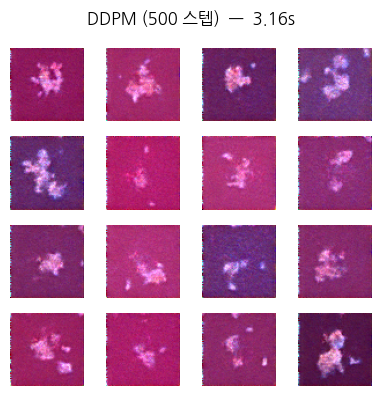

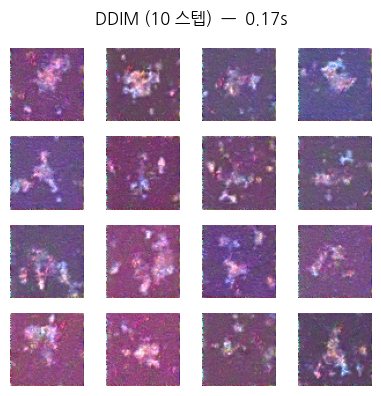

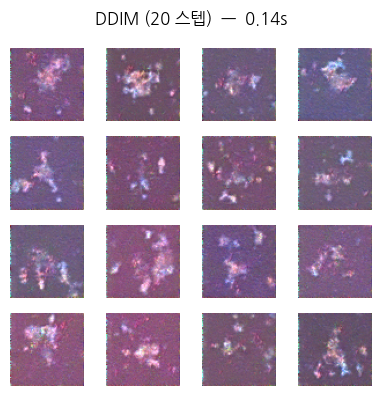

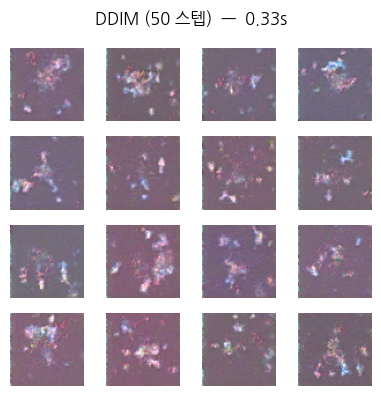

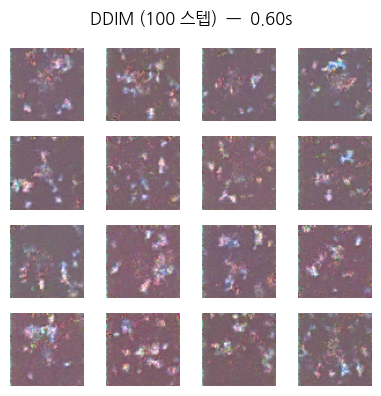

In [16]:
# 8.1 각 설정의 생성 샘플 표시
for name,k,sec,g in configs:
    show_images(g, f"{name}  —  {sec:.2f}s")

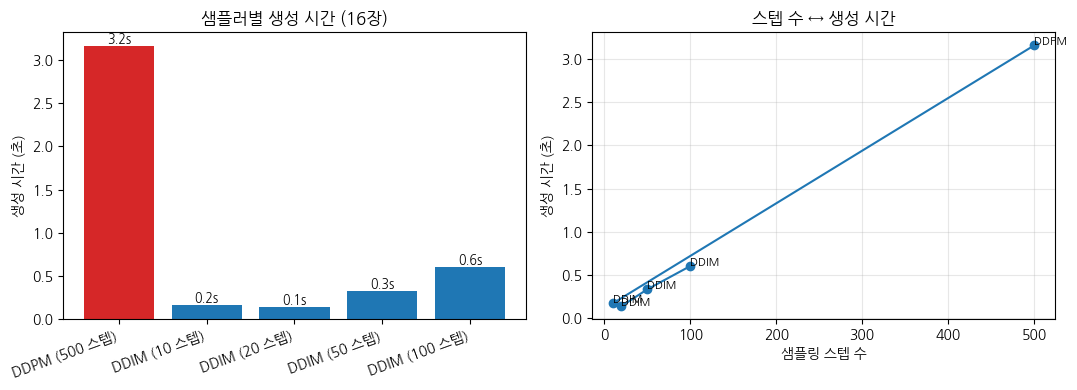


=== 요약 ===
DDPM (500 스텝)    | 스텝  500 |   3.16s | DDPM 대비   1.0x 빠름
DDIM (10 스텝)     | 스텝   10 |   0.17s | DDPM 대비  18.7x 빠름
DDIM (20 스텝)     | 스텝   20 |   0.14s | DDPM 대비  23.2x 빠름
DDIM (50 스텝)     | 스텝   50 |   0.33s | DDPM 대비   9.5x 빠름
DDIM (100 스텝)    | 스텝  100 |   0.60s | DDPM 대비   5.3x 빠름


In [17]:
# 8.2 속도 비교 막대그래프 + 스텝수 대비 시간
names=[c[0] for c in configs]; steps=[c[1] for c in configs]; secs=[c[2] for c in configs]
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].bar(range(len(names)), secs, color=["#d62728"]+["#1f77b4"]*4)
ax[0].set_xticks(range(len(names))); ax[0].set_xticklabels(names, rotation=20, ha="right")
ax[0].set_ylabel("생성 시간 (초)"); ax[0].set_title("샘플러별 생성 시간 (16장)")
for i,s in enumerate(secs): ax[0].text(i, s, f"{s:.1f}s", ha="center", va="bottom", fontsize=9)

ax[1].plot(steps, secs, "o-")
for n,st,se in zip(names,steps,secs): ax[1].annotate(n.split()[0], (st,se), fontsize=8)
ax[1].set_xlabel("샘플링 스텝 수"); ax[1].set_ylabel("생성 시간 (초)")
ax[1].set_title("스텝 수 ↔ 생성 시간"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig("speed_compare.png", dpi=120); plt.show()

print("\n=== 요약 ===")
ref=secs[0]
for n,st,se in zip(names,steps,secs):
    print(f"{n:16s} | 스텝 {st:4d} | {se:6.2f}s | DDPM 대비 {ref/se:5.1f}x 빠름")

### 8.3 DDIM 결정론(eta=0) vs 확률(eta=1) 추가 비교 (선택)

같은 50 스텝에서 eta 만 바꿔, DDIM 의 결정론적 샘플링과 확률적 샘플링 차이를 본다.

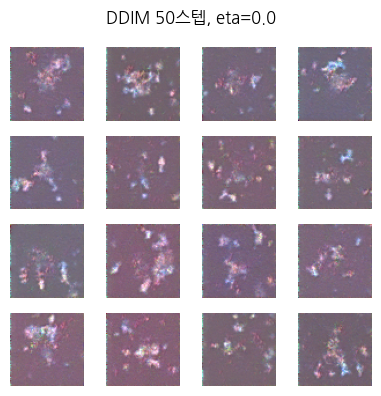

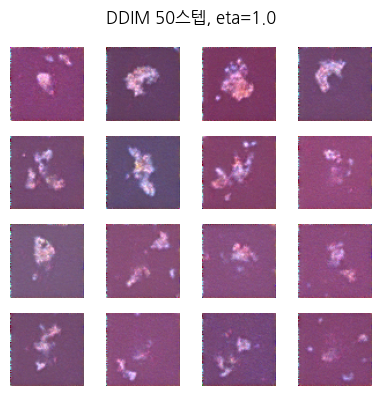

In [18]:
for e in [0.0, 1.0]:
    torch.manual_seed(123)
    g=sample_ddim(diff, n_samples=16, n_ddim=50, eta=e, device=device,
                  c=CHANNELS,h=IMG_SIZE,w=IMG_SIZE)
    show_images(g, f"DDIM 50스텝, eta={e}")